# Exploring the Gaussian Function

We will visualize the Gaussian

$$
g(x) = \exp\left(-\frac{x^2}{2\sigma^2}\right)
$$

where:

- $x$ is the input variable
- $\sigma$ controls the width of the curve

Larger $\sigma$ values produce a wider, flatter bell curve, while smaller $\sigma$ values produce a narrower, sharper peak.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import FloatSlider, Checkbox, interact

x = np.linspace(-10, 10, 1000)


def gaussian(x, sigma=1.0, mu=0.0, normalized=False):
    sigma = max(float(sigma), 1e-6)
    exponent = -((x - mu) ** 2) / (2 * sigma**2)
    values = np.exp(exponent)

    if normalized:
        values = values / (sigma * np.sqrt(2 * np.pi))

    return values

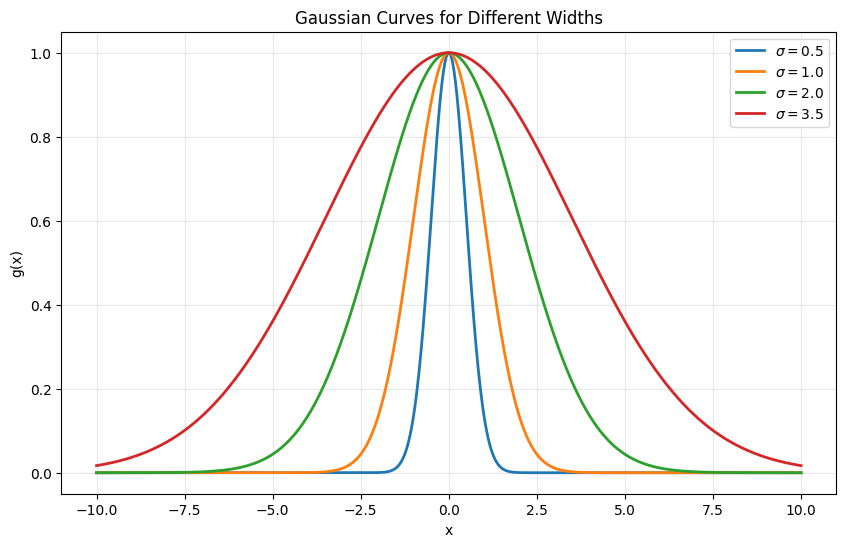

In [3]:
sigmas = [0.5, 1.0, 2.0, 3.5]

plt.figure(figsize=(10, 6))
for sigma in sigmas:
    plt.plot(x, gaussian(x, sigma=sigma), label=fr"$\sigma = {sigma}$", linewidth=2)

plt.title("Gaussian Curves for Different Widths")
plt.xlabel("x")
plt.ylabel("g(x)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [4]:
def plot_gaussian(sigma=1.0, mu=0.0, normalized=False, show_half_max=True):
    y = gaussian(x, sigma=sigma, mu=mu, normalized=normalized)

    plt.figure(figsize=(10, 6))
    plt.plot(x, y, color="crimson", linewidth=3, label="Gaussian")

    if show_half_max:
        half_height = y.max() / 2
        plt.axhline(half_height, color="navy", linestyle="--", alpha=0.7, label="Half maximum")

    plt.title(f"Interactive Gaussian: sigma={sigma:.2f}, mu={mu:.2f}")
    plt.xlabel("x")
    plt.ylabel("g(x)")
    plt.ylim(bottom=0)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()


interact(
    plot_gaussian,
    sigma=FloatSlider(value=1.0, min=0.2, max=5.0, step=0.1, description="sigma"),
    mu=FloatSlider(value=0.0, min=-4.0, max=4.0, step=0.1, description="mu"),
    normalized=Checkbox(value=False, description="normalized"),
    show_half_max=Checkbox(value=True, description="half max")
);

interactive(children=(FloatSlider(value=1.0, description='sigma', max=5.0, min=0.2), FloatSlider(value=0.0, de…

## What does $\mu$ mean?

In the interactive Gaussian plot, $\mu$ is the center of the curve. It controls the horizontal position of the bell shape.

$$
g(x) = \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right)
$$

Here:

$$
\mu = \text{mean or location parameter}
$$

Interpretation:

- If $\mu = 0$, the peak is centered at $x = 0$
- If $\mu > 0$, the curve shifts to the right
- If $\mu < 0$, the curve shifts to the left

So, $\sigma$ controls the width, while $\mu$ controls the location of the peak.

## Fourier Transform of a Gaussian

For the Gaussian

$$
g(x) = \exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right),
$$

using the convention

$$
G(k) = \int_{-\infty}^{\infty} g(x)e^{-ikx}\,dx,
$$

the Fourier transform is

$$
G(k) = \sqrt{2\pi}\,\sigma\,\exp\left(-\frac{\sigma^2 k^2}{2}\right)e^{-ik\mu}.
$$

Key ideas:

- The Fourier transform of a Gaussian is another Gaussian.
- Larger $\sigma$ in $x$ makes the transform narrower in frequency $k$.
- The parameter $\mu$ shifts the Gaussian in $x$, and adds a complex phase factor $e^{-ik\mu}$ in the Fourier domain.
- Because of that phase factor, changing $\mu$ does not change the magnitude $|G(k)|$, but it does change the real and imaginary parts.

In [ ]:
k = np.linspace(-8, 8, 1000)


def gaussian_fourier_transform(k, sigma=1.0, mu=0.0):
    sigma = max(float(sigma), 1e-6)
    return np.sqrt(2 * np.pi) * sigma * np.exp(-(sigma**2) * (k**2) / 2) * np.exp(-1j * k * mu)



def plot_gaussian_and_ft(sigma=1.0, mu=0.0):
    y = gaussian(x, sigma=sigma, mu=mu)
    G = gaussian_fourier_transform(k, sigma=sigma, mu=mu)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(x, y, color="crimson", linewidth=3)
    axes[0].axvline(mu, color="black", linestyle="--", alpha=0.6, label=fr"$\mu={mu:.2f}$")
    axes[0].set_title(f"Gaussian in x-space (sigma={sigma:.2f}, mu={mu:.2f})")
    axes[0].set_xlabel("x")
    axes[0].set_ylabel("g(x)")
    axes[0].grid(True, alpha=0.3)
    axes[0].legend()

    axes[1].plot(k, np.abs(G), color="navy", linewidth=3, label=r"$|G(k)|$")
    axes[1].plot(k, np.real(G), color="darkgreen", linestyle="--", linewidth=2, label=r"$\Re(G(k))$")
    axes[1].plot(k, np.imag(G), color="darkorange", linestyle=":", linewidth=2, label=r"$\Im(G(k))$")
    axes[1].set_title("Fourier transform in k-space")
    axes[1].set_xlabel("k")
    axes[1].set_ylabel("Amplitude")
    axes[1].grid(True, alpha=0.3)
    axes[1].legend()

    plt.tight_layout()
    plt.show()


interact(
    plot_gaussian_and_ft,
    sigma=FloatSlider(value=1.0, min=0.2, max=4.0, step=0.1, description="sigma"),
    mu=FloatSlider(value=0.0, min=-4.0, max=4.0, step=0.1, description="mu")
);

interactive(children=(FloatSlider(value=1.0, description='sigma', max=4.0, min=0.2), FloatSlider(value=0.0, de…